# I hope everyone is safe


# A FRIENDLY MESSAGE


Hi Below is my first submission to the ever famous house price regression competition.The dataset for beginners into kaggle, I realized a lot of kernels to be full of long codes that intimidated me as a beginner. I landed up at top 22% in my 17th submission. Learned a lot in the process and looking forward to keep going on with other submissions.

I know it is a very common problem set for anyone to submit and upload a kernel but I thought of sharing it anyway to share my approach hoping to get feedbacks from the community on how I can improve.

Here I've tried to optimize my code and still providing the best results which I believe will not be intimidating for beginners and learners who are trying to get their first submission.

I have taken a very basic approach and I hope you find it useful. If you do, please upvote, it'll just motivate me more to keep trying more and more problems.

HOPING TO HEAR FROM YOU ALL. THANK YOU IN ADVANCE :)


My main objectives on this project are:

* Applying exploratory data analysis and trying to get some insights about our dataset
* Getting data in better shape by transforming and feature engineering to help us in building better models
* Building and tuning couple models to get some stable results on predicting housing prices

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/test.csv
/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv


# Meeting the data
We're going to start by loading the data and taking first look on it as usual. For the column names we have great dictionary file in our dataset location so we can get familiar with them in no time. I highly recommend looking at that before you start working on the dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
df_test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

In [4]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
df_train.shape

(1460, 81)

In [7]:
df_test.shape

(1459, 80)

as we can see that in train there are 1460 rows with 81 columns and in test dataset 1459 rows with 80 columns. our dependent varibale is **'SalePrice'**

In [8]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
df_test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [10]:
df_train.columns , df_test.columns

(Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
        'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
        'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
        'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
        'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
        'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
        'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
        'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
        'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
        'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
        'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
        'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
        'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
        'GarageCond

We have 1460 observations of 80 variables in the training dataframe. The variables are described below:

SalePrice - This is the target variable/dependent variable that you're trying to predict.

* MSSubClass: The building class
* MSZoning: The general zoning classification
* LotFrontage: Linear feet of street connected to property
* LotArea: Lot size in square feet
* Street: Type of road access
* Alley: Type of alley access
* LotShape: General shape of property
* LandContour: Flatness of the property
* Utilities: Type of utilities available
* LotConfig: Lot configuration
* LandSlope: Slope of property
* Neighborhood: Physical locations within Ames city limits
* Condition1: Proximity to main road or railroad
* Condition2: Proximity to main road or railroad (if a second is present)
* BldgType: Type of dwelling
* HouseStyle: Style of dwelling
* OverallQual: Overall material and finish quality
* OverallCond: Overall condition rating
* YearBuilt: Original construction date
* YearRemodAdd: Remodel date
* RoofStyle: Type of roof
* RoofMatl: Roof material
* Exterior1st: Exterior covering on house
* Exterior2nd: Exterior covering on house (if more than one material)
* MasVnrType: Masonry veneer type
* MasVnrArea: Masonry veneer area in square feet
* ExterQual: Exterior material quality
* ExterCond: Present condition of the material on the exterior
* Foundation: Type of foundation
* BsmtQual: Height of the basement
* BsmtCond: General condition of the basement
* BsmtExposure: Walkout or garden level basement walls
* BsmtFinType1: Quality of basement finished area
* BsmtFinSF1: Type 1 finished square feet
* BsmtFinType2: Quality of second finished area (if present)
* BsmtFinSF2: Type 2 finished square feet
* BsmtUnfSF: Unfinished square feet of basement area
* TotalBsmtSF: Total square feet of basement area
* Heating: Type of heating
* HeatingQC: Heating quality and condition
* CentralAir: Central air conditioning
* Electrical: Electrical system
* 1stFlrSF: First Floor square feet
* 2ndFlrSF: Second floor square feet
* LowQualFinSF: Low quality finished square feet (all floors)
* GrLivArea: Above grade (ground) living area square feet
* BsmtFullBath: Basement full bathrooms
* BsmtHalfBath: Basement half bathrooms
* FullBath: Full bathrooms above grade
* HalfBath: Half baths above grade
* Bedroom: Number of bedrooms above basement level
* Kitchen: Number of kitchens
* KitchenQual: Kitchen quality
* TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
* Functional: Home functionality rating Fireplaces: Number of fireplaces
* FireplaceQu: Fireplace quality
* GarageType: Garage location
* GarageYrBlt: Year garage was built
* GarageFinish: Interior finish of the garage
* GarageCars: Size of garage in car capacity
* GarageArea: Size of garage in square feet
* GarageQual: Garage quality
* GarageCond: Garage condition
* PavedDrive: Paved driveway
* WoodDeckSF: Wood deck area in square feet
* OpenPorchSF: Open porch area in square feet
* EnclosedPorch: Enclosed porch area in square feet
* 3SsnPorch: Three season porch area in square feet
* ScreenPorch: Screen porch area in square feet
* PoolArea: Pool area in square feet
* PoolQC: Pool quality
* Fence: Fence quality
* MiscFeature: Miscellaneous feature not covered in other categories
* MiscVal: $Value of miscellaneous feature
* MoSold: Month Sold
* YrSold: Year Sold
* SaleType: Type of sale
* SaleCondition: Condition of sale

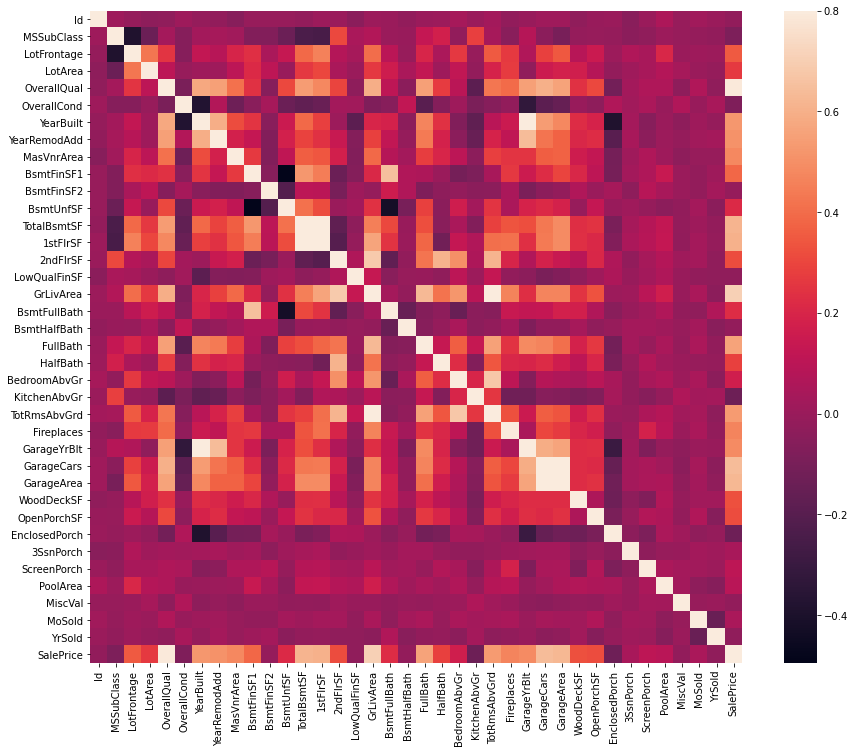

In [11]:
#correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
corrmat = df_train.corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corrmat, vmax=.8, square=True)

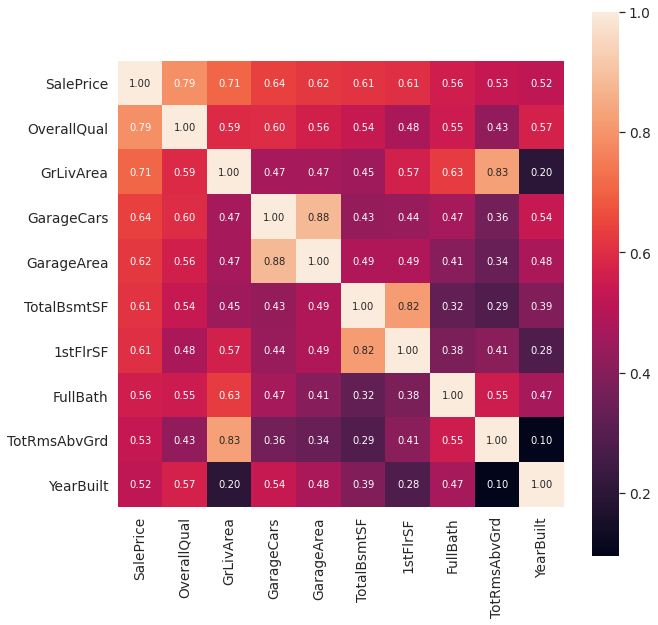

In [12]:
#saleprice correlation matrix
k = 10 #number of variables for heatmap
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize=(10,10))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

**so what is log transformation:-log transformation is used to transform skewed data to approximately conform to normality.**

In [ ]:
'''#before log transformation
sns.distplot(df_train['SalePrice']);
fig_saleprice = plt.figure(figsize=(12,5))
result1 = stats.probplot(df_train['SalePrice'],plot = plt)'''

In [ ]:
'''#applying log transformation
df_train['SalePrice'] = np.log(df_train['SalePrice'])'''

In [ ]:
'''#after log transformation
sns.distplot(df_train['SalePrice']);
fig_saleprice2 = plt.figure(figsize=(12,5))
result3 = stats.probplot(df_train['SalePrice'],plot = plt)'''

below code is used to see top 10 highly correlated columns with saleprice in which OverallQual,GrLiveArea,Garagecars,GarageArea,TotalBsmtSF and 1stFlrSF are highly correlated      

In [13]:
#below code is used to see which column is more correlated to dependent varibale so first ten columns are more correlated compare to other columns
corr = df_train.corr()["SalePrice"]
corr[np.argsort(corr, axis=0)[::-1]]

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

# **OUTLIERS**

we are going to plot first 10 highly correlated columns to see how many outliers we have in our dataset

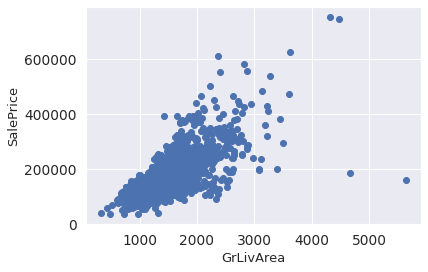

In [14]:
fig = plt.subplots()
plt.scatter(x = df_train['GrLivArea'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()


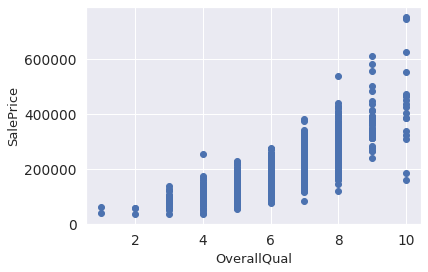

In [15]:
fig1= plt.subplots()
plt.scatter(x = df_train['OverallQual'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('OverallQual', fontsize=13)
plt.show()

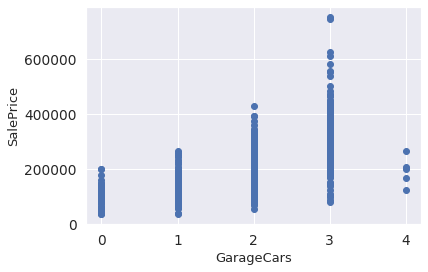

In [16]:
fig2= plt.subplots()
plt.scatter(x = df_train['GarageCars'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GarageCars', fontsize=13)
plt.show()

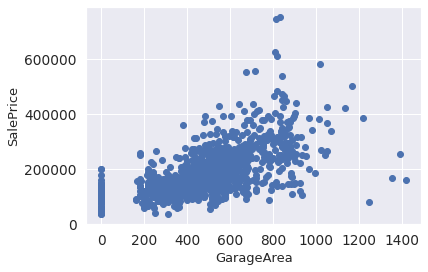

In [17]:
fig3= plt.subplots()
plt.scatter(x = df_train['GarageArea'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GarageArea', fontsize=13)
plt.show()

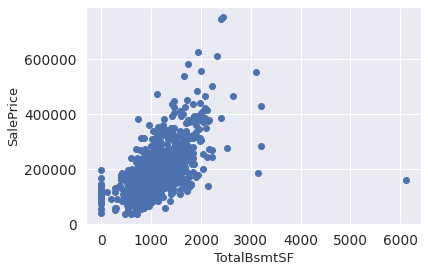

In [18]:
fig4= plt.subplots()
plt.scatter(x = df_train['TotalBsmtSF'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('TotalBsmtSF', fontsize=13)
plt.show()

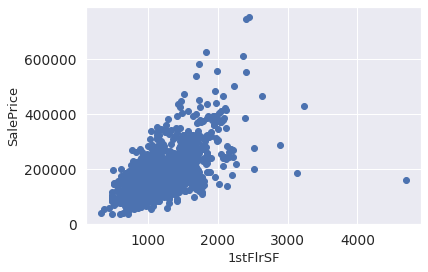

In [19]:
fig5= plt.subplots()
plt.scatter(x = df_train['1stFlrSF'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('1stFlrSF', fontsize=13)
plt.show()

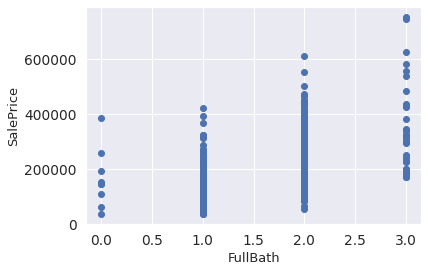

In [20]:
fig6= plt.subplots()
plt.scatter(x = df_train['FullBath'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('FullBath', fontsize=13)
plt.show()

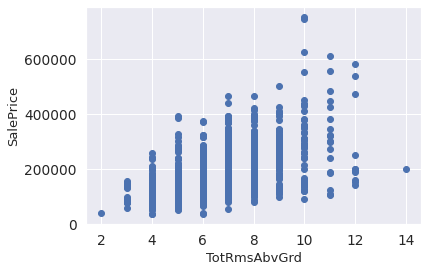

In [21]:
fig7= plt.subplots()
plt.scatter(x = df_train['TotRmsAbvGrd'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('TotRmsAbvGrd', fontsize=13)
plt.show()

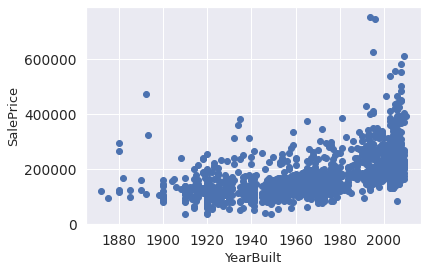

In [22]:
fig8= plt.subplots()
plt.scatter(x = df_train['YearBuilt'], y = df_train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('YearBuilt', fontsize=13)
plt.show()

i have seen lots of notebooks in which they delete outliers but i am not going to do it because if i do my accuracy will be decrease. i don't know why if you know then just tell me in comment box.it will be appreciated.

but below i am adding that code incase someone want it.

In [ ]:
'''#deleting outliers
df = df.drop(df[(df['GrLivArea']>4000) & (df['SalePrice']<300000)].index)
df = df.drop(df[(df['GarageArea']>1200) & (df['SalePrice']<500000)].index)
df = df.drop(df[(df['TotalBsmtSF']>3000) & (df['SalePrice']<700000)].index)
df = df.drop(df[(df['1stFlrSF']>2700) & (df['1stFlrSF']<700000)].index)'''

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:2079: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


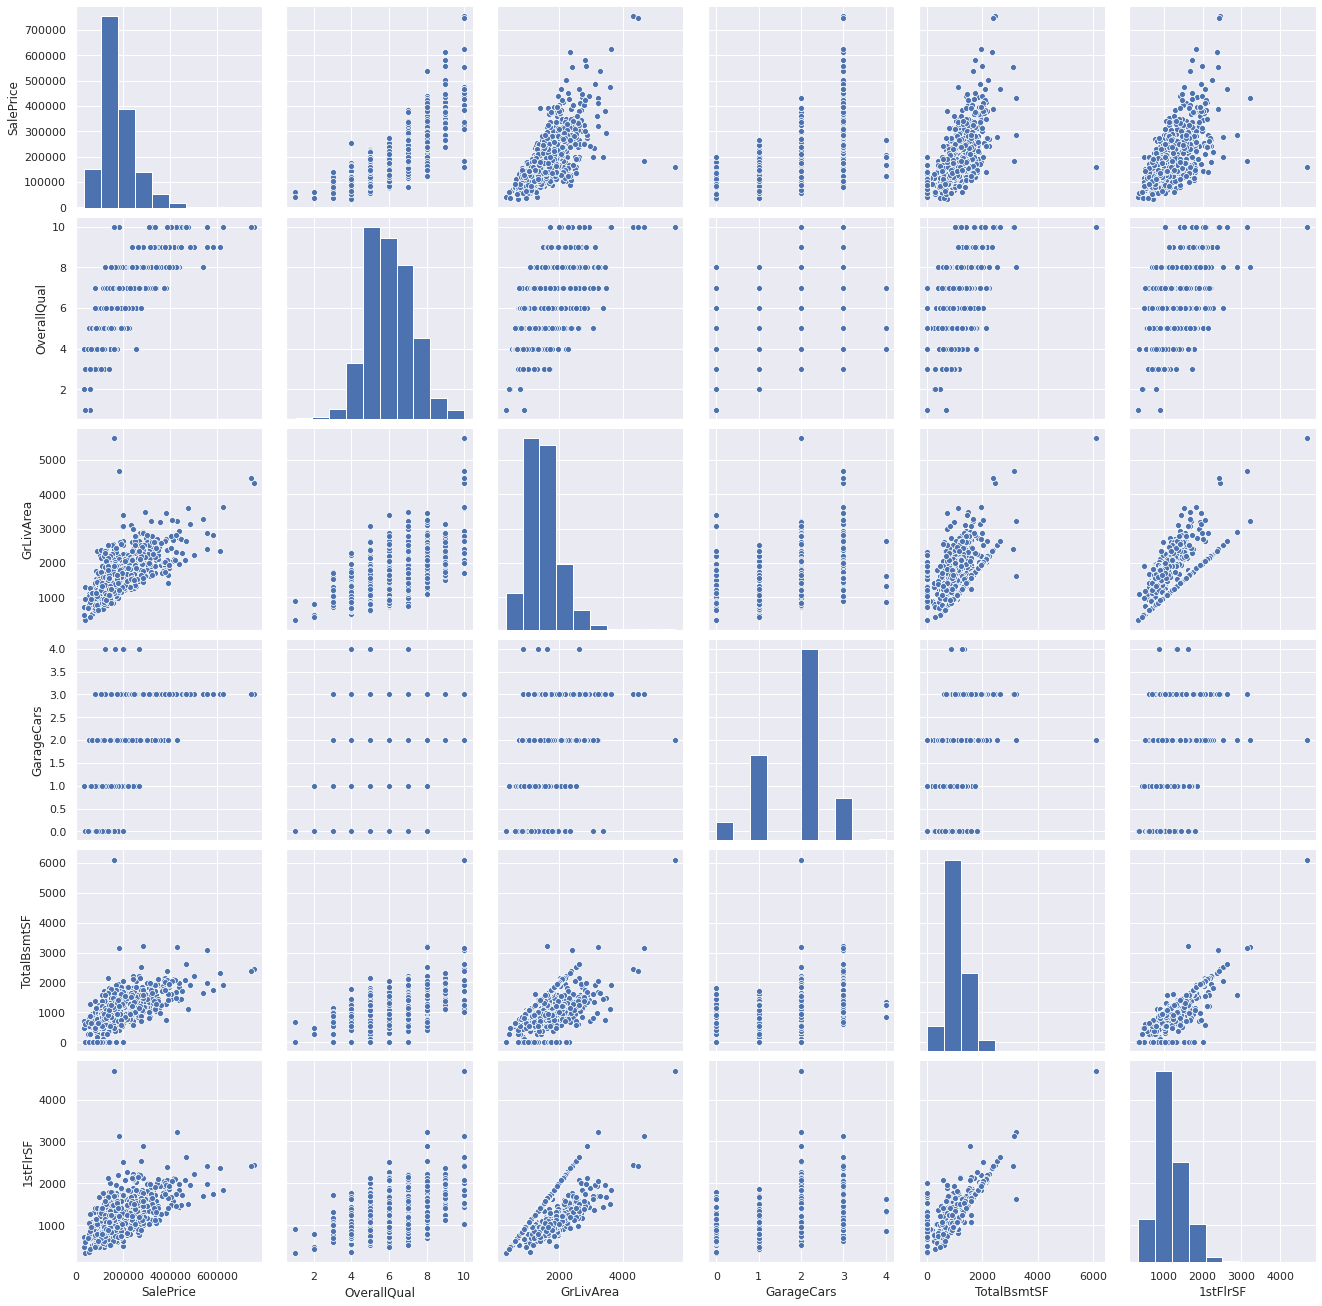

In [29]:
#scatterplot
sns.set()
columns = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF']
sns.pairplot(df_train[columns], size = 3)
plt.show();

# some feature engineering

here i have merged some columns to just reduce complexity i have tried with all the columns but i didn't get this much accuracy which i am getting right now

In [30]:
#feature engineering
df_train['TotalSF'] = df_train['TotalBsmtSF']+df_train['1stFlrSF']+df_train['2ndFlrSF']
df_train=df_train.drop(columns={'1stFlrSF', '2ndFlrSF','TotalBsmtSF'})
df_train['wholeExterior'] = df_train['Exterior1st']+df_train['Exterior2nd']
df_train=df_train.drop(columns={'Exterior1st','Exterior2nd'})
df_train['Bsmt'] = df_train['BsmtFinSF1']+ df_train['BsmtFinSF2']
df_train = df_train.drop(columns={'BsmtFinSF1','BsmtFinSF2'})
df_train['TotalBathroom'] = df_train['FullBath'] + df_train['HalfBath']
df_train = df_train.drop(columns={'FullBath','HalfBath'})


df_test['TotalSF'] = df_test['TotalBsmtSF']+df_test['1stFlrSF']+df_test['2ndFlrSF']
df_test=df_test.drop(columns={'1stFlrSF', '2ndFlrSF','TotalBsmtSF'})
df_test['wholeExterior'] = df_test['Exterior1st']+df_test['Exterior2nd']
df_test=df_test.drop(columns={'Exterior1st','Exterior2nd'})
df_test['Bsmt'] = df_test['BsmtFinSF1']+ df_test['BsmtFinSF2']
df_test = df_test.drop(columns={'BsmtFinSF1','BsmtFinSF2'})
df_test['TotalBathroom'] = df_test['FullBath'] + df_test['HalfBath']
df_test = df_test.drop(columns={'FullBath','HalfBath'})

**We're going to merge the datasets here before we start editing it so we don't have to do these operations twice. Let's call it features since it has features only. So our data has 2919 observations and 79 features to begin with...**

In [31]:
frames = [df_train,df_test]
df = pd.concat(frames,keys=['train','test'])

There are 2919 observations with 76 columns. including the target variable SalePrice and Id.The train set has 1460 observations while the test set has 1459 observations, the target variable SalePrice is absent in test. The aim of this study is to train a model on the train set and use it to predict the target SalePrice of the test set.

In [32]:
df

Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley  \
train 0        1          60       RL         65.0     8450   Pave   NaN   
      1        2          20       RL         80.0     9600   Pave   NaN   
      2        3          60       RL         68.0    11250   Pave   NaN   
      3        4          70       RL         60.0     9550   Pave   NaN   
      4        5          60       RL         84.0    14260   Pave   NaN   
...          ...         ...      ...          ...      ...    ...   ...   
test  1454  2915         160       RM         21.0     1936   Pave   NaN   
      1455  2916         160       RM         21.0     1894   Pave   NaN   
      1456  2917          20       RL        160.0    20000   Pave   NaN   
      1457  2918          85       RL         62.0    10441   Pave   NaN   
      1458  2919          60       RL         74.0     9627   Pave   NaN   

           LotShape LandContour Utilities  ... MiscVal MoSold YrSold SaleType  \
train 0         Reg         Lvl    AllPub  ...       0      2   2008       WD   
      1         Reg         Lvl    AllPub  ...       0      5   2007       WD   
      2         IR1         Lvl    AllPub  ...       0      9   2008       WD   
      3         IR1         Lvl    AllPub  ...       0      2   2006       WD   
      4         IR1         Lvl    AllPub  ...       0     12   2008       WD   
...             ...         ...       ...  ...     ...    ...    ...      ...   
test  1454      Reg         Lvl    AllPub  ...       0      6   2006       WD   
      1455      Reg         Lvl    AllPub  ...       0      4   2006       WD   
      1456      Reg         Lvl    AllPub  ...       0      9   2006       WD   
      1457      Reg         Lvl    AllPub  ...     700      7   2006       WD   
      1458      Reg         Lvl    AllPub  ...       0     11   2006       WD   

           SaleCondition SalePrice TotalSF   wholeExterior    Bsmt  \
train 0           Normal  208500.0  2566.0  VinylSdVinylSd   706.0   
      1           Normal  181500.0  2524.0  MetalSdMetalSd   978.0   
      2           Normal  223500.0  2706.0  VinylSdVinylSd   486.0   
      3          Abnorml  140000.0  2473.0  Wd SdngWd Shng   216.0   
      4           Normal  250000.0  3343.0  VinylSdVinylSd   655.0   
...                  ...       ...     ...             ...     ...   
test  1454        Normal       NaN  1638.0  CemntBdCmentBd     0.0   
      1455       Abnorml       NaN  1638.0  CemntBdCmentBd   252.0   
      1456       Abnorml       NaN  2448.0  VinylSdVinylSd  1224.0   
      1457        Normal       NaN  1882.0  HdBoardWd Shng   337.0   
      1458        Normal       NaN  2996.0  HdBoardHdBoard   758.0   

            TotalBathroom  
train 0                 3  
      1                 2  
      2                 3  
      3                 1  
      4                 3  
...                   ...  
test  1454              2  
      1455              2  
      1456              1  
      1457              1  
      1458              3  

[2919 rows x 76 columns]

In [33]:
df_missing=df.isnull().sum().sort_values(ascending=False)

In [34]:
df_missing

PoolQC         2909
MiscFeature    2814
Alley          2721
Fence          2348
SalePrice      1459
               ... 
CentralAir        0
HeatingQC         0
Heating           0
Foundation        0
Id                0
Length: 76, dtype: int64

now we are saperating categorical columns and numerical columns for filling missing values

In [35]:
cat_col = df.select_dtypes(include=['object'])
cat_col.isnull().sum()
cat_col.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition',
       'wholeExterior'],
      dtype='object')

In [36]:
num_col = df.select_dtypes(include=['int64', 'float64'])
num_col.isnull().sum()
num_col.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtUnfSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice', 'TotalSF', 'Bsmt', 'TotalBathroom'],
      dtype='object')

In below cell you have your numerical columns so i just replace NaN by 0. I have also tried mode,median and mean but i got best result in 0.if you want to do it then just fork my notebook and apply that functions.if you want that other function's code then just comment below i will give you the code in comment section.

# Handling Missing Data

# numerical columns

In [37]:
# handling missing values of numerical columns
df['LotFrontage'] = df['LotFrontage'].fillna(value=0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(value=0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(value=0)
df['BsmtFullBath'] = df['BsmtFullBath'].fillna(value=0)
df['BsmtHalfBath'] = df['BsmtHalfBath'].fillna(value=0)
df['GarageArea'] = df['GarageArea'].fillna(value=0)
df['GarageCars'] = df['GarageCars'].fillna(value=0)
df['BsmtUnfSF'] = df['BsmtUnfSF'].fillna(value=0)
df['Bsmt'] = df['Bsmt'].fillna(value=0)
df['TotalSF'] = df['TotalSF'].fillna(value=0)

i have applied same technique as i applied in numerical columns where i put 0 and here i have replaced all the NaN values with None.That means if the original dataset have nan values , it means that the particular house is doesn't have that thing.for example, if id no = 220 do not have garage then why we put values that id no = 220 has a garage.

so i replaced them with None.

# categorical columns

In [38]:
# handling missing values of categorical columns
df['MSZoning'] = df['MSZoning'].fillna(value='None')
df['GarageQual'] = df['GarageQual'].fillna(value='None')
df['GarageCond'] = df['GarageCond'].fillna(value='None')
df['GarageFinish'] = df['GarageFinish'].fillna(value='None')
df['GarageType'] = df['GarageType'].fillna(value='None')
df['BsmtExposure'] = df['BsmtExposure'].fillna(value='None')
df['BsmtCond'] = df['BsmtCond'].fillna(value='None')
df['BsmtQual'] = df['BsmtQual'].fillna(value='None')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna(value='None')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(value='None')
df['MasVnrType'] = df['MasVnrType'].fillna(value='None')
df['Utilities'] = df['Utilities'].fillna(value='None')
df['Functional'] = df['Functional'].fillna(value='None')
df['Electrical'] = df['Electrical'].fillna(value='None')
df['KitchenQual'] = df['KitchenQual'].fillna(value='None')
df['SaleType'] = df['SaleType'].fillna(value='None')
df['wholeExterior'] = df['wholeExterior'].fillna(value='None')

**most missing values columns**


**PoolQC**           2909


**MiscFeature**      2814


**Alley**            2721


**Fence**            2348


**FireplaceQu**      1420  

as you can see above this five columns has more missing values arounf 90% + so i decided to drop them.

In [39]:
df = df.drop(columns={'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'})

In [40]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'BsmtUnfSF', 'Heating', 'HeatingQC', 'CentralAir',
       'Electrical', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType',
       'SaleConditio

In [41]:
df_main = pd.get_dummies(df)
df_main

Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
train 0        1          60         65.0     8450            7            5   
      1        2          20         80.0     9600            6            8   
      2        3          60         68.0    11250            7            5   
      3        4          70         60.0     9550            7            5   
      4        5          60         84.0    14260            8            5   
...          ...         ...          ...      ...          ...          ...   
test  1454  2915         160         21.0     1936            4            7   
      1455  2916         160         21.0     1894            4            5   
      1456  2917          20        160.0    20000            5            7   
      1457  2918          85         62.0    10441            5            5   
      1458  2919          60         74.0     9627            7            5   

            YearBuilt  YearRemodAdd  MasVnrArea  BsmtUnfSF  ...  \
train 0          2003          2003       196.0      150.0  ...   
      1          1976          1976         0.0      284.0  ...   
      2          2001          2002       162.0      434.0  ...   
      3          1915          1970         0.0      540.0  ...   
      4          2000          2000       350.0      490.0  ...   
...               ...           ...         ...        ...  ...   
test  1454       1970          1970         0.0      546.0  ...   
      1455       1970          1970         0.0      294.0  ...   
      1456       1960          1996         0.0        0.0  ...   
      1457       1992          1992         0.0      575.0  ...   
      1458       1993          1994        94.0      238.0  ...   

            wholeExterior_Wd SdngStone  wholeExterior_Wd SdngStucco  \
train 0                              0                            0   
      1                              0                            0   
      2                              0                            0   
      3                              0                            0   
      4                              0                            0   
...                                ...                          ...   
test  1454                           0                            0   
      1455                           0                            0   
      1456                           0                            0   
      1457                           0                            0   
      1458                           0                            0   

            wholeExterior_Wd SdngVinylSd  wholeExterior_Wd SdngWd Sdng  \
train 0                                0                             0   
      1                                0                             0   
      2                                0                             0   
      3                                0                             0   
      4                                0                             0   
...                                  ...                           ...   
test  1454                             0                             0   
      1455                             0                             0   
      1456                             0                             0   
      1457                             0                             0   
      1458                             0                             0   

            wholeExterior_Wd SdngWd Shng  wholeExterior_WdShingHdBoard  \
train 0                                0                             0   
      1                                0                             0   
      2                                0                             0   
      3                                1                             0   
      4                                0                             0   
...                                  ...                      

In [42]:
df_main.shape

(2919, 339)

i am going to plot a heatmap for just fun so if you don't understand it go ahead even i don't understand this below heatmap.LOL

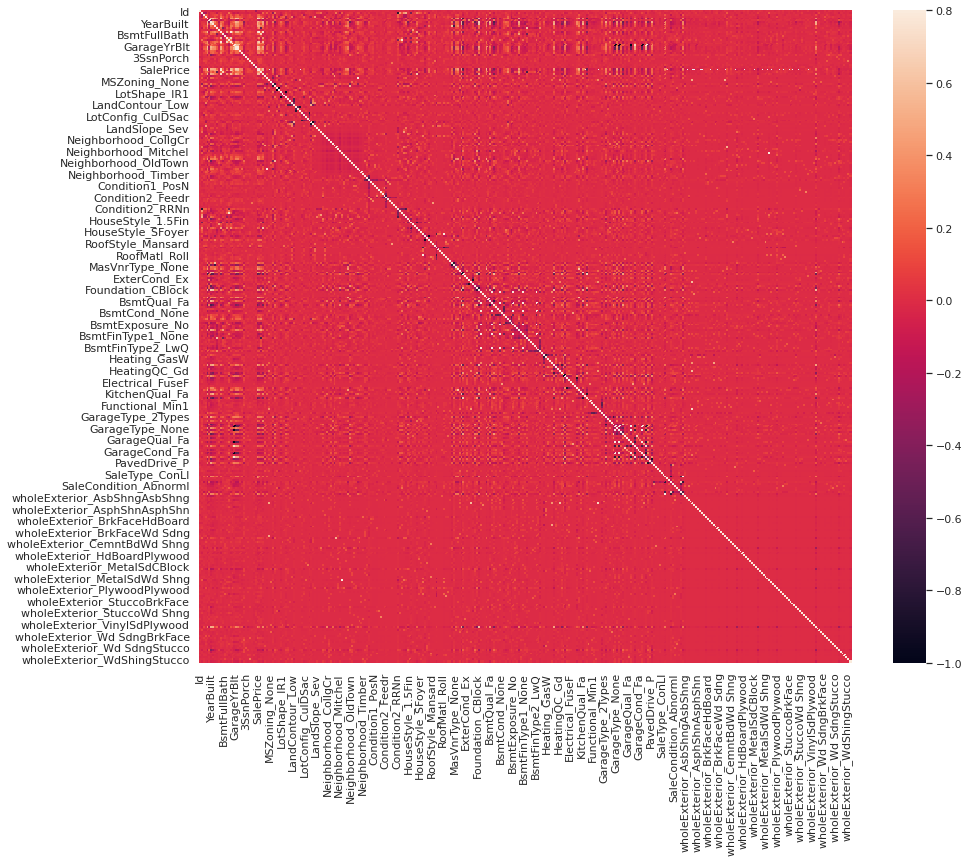

In [43]:
#correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns
corrmat = df_main.corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corrmat, vmax=.8, square=True)

top 40 correlated columns after data preprocessing

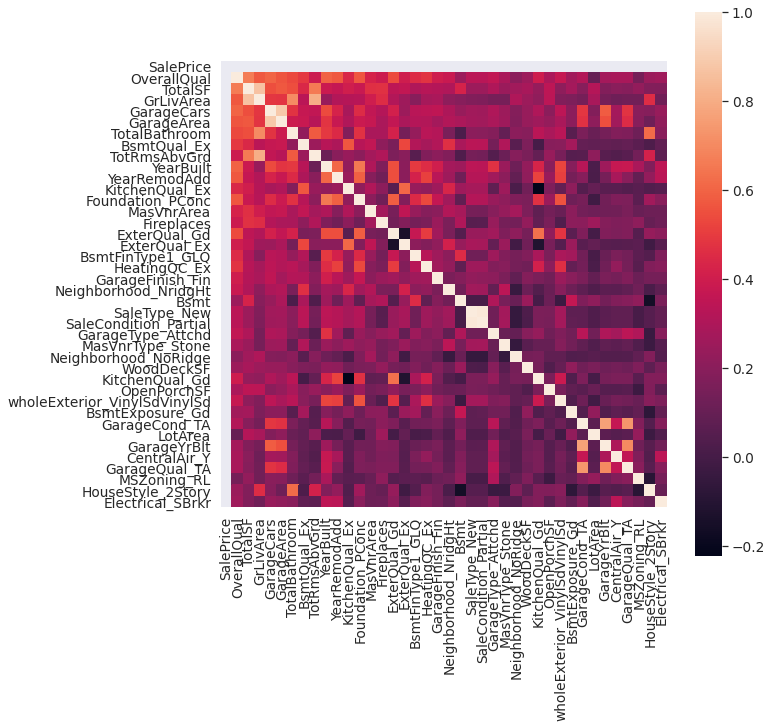

In [44]:
#saleprice correlation matrix
k = 40 #number of variables for heatmap
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_main[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize=(10,10))
hm = sns.heatmap(cm, cbar=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [45]:
EID = df_main.loc['test']
df_test = df_main.loc['test']
df_train = df_main.loc['train']
EID = EID.Id

In [46]:
df_test.drop(['SalePrice','Id'], axis =1, inplace=True)

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3997: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [47]:
X_train = df_train.drop(['SalePrice','Id'], axis = 1)
y_train = df_train['SalePrice']

In [48]:
import xgboost
xgboost = xgboost.XGBRegressor(learning_rate=0.05,
                      colsample_bytree = 0.5,
                      subsample = 0.8,
                      n_estimators=1000,
                      max_depth=5,
                      gamma=5)

xgboost.fit(X_train, y_train)
y_pred = xgboost.predict(df_test)

In [49]:
y_pred 

array([127460.266, 167904.98 , 190090.47 , ..., 174666.9  , 118745.85 ,
       218983.38 ], dtype=float32)

In [50]:
#making main csv file
main_submission = pd.DataFrame({'Id': EID, 'SalePrice': y_pred})

main_submission.to_csv("submission.csv", index=False)
main_submission.head()

,Id,SalePrice
0,1461,127460.265625
1,1462,167904.984375
2,1463,190090.468750
3,1464,194979.375000
4,1465,186563.484375


# please do *upvote* if you like